In [12]:
# Instalación de librerías
!pip3 install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
pd.set_option('display.max_columns', 100)
sns.set_theme(style='darkgrid')


In [2]:
# Carga de datos
df = pd.read_csv('data/loan.csv', low_memory=False)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")

Dimensiones del dataset: (2260668, 145)
Filas: 2,260,668 | Columnas: 145


Se observan 2.2 millones de prestamos y 145 variables. 

In [3]:
# Vista general del dataset
print("=== PRIMERAS FILAS ===")
display(df.head())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes.value_counts())

print("\n=== INFORMACIÓN GENERAL ===")
df.info(verbose=False, memory_usage='deep')

=== PRIMERAS FILAS ===


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,...,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,...,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,...,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,490xx,MI,10.51,0.0,Apr-2011,0.0,NaN,NaN,8.0,0.0,4599,19.1,13.0,w,4787.21,4787.21,353.89,353.89,212.79,141.10,0.0,0.0,0.0,Feb-2019,180.69,Mar-2019,Feb-2019,0.0,...,6.0,7.0,3.0,8.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,136927.0,11749.0,13800.0,10000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,985xx,WA,16.74,0.0,Feb-2006,0.0,NaN,NaN,10.0,0.0,5468,78.1,13.0,w,3831.93,3831.93,286.71,286.71,168.07,118.64,0.0,0.0,0.0,Feb-2019,146.51,Mar-2019,Feb-2019,0.0,...,2.0,3.0,2.0,10.0,0.0,0.0,0.0,3.0,100.0,100.0,0.0,0.0,385183.0,36151.0,5000.0,44984.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidati


=== TIPOS DE DATOS ===
float64    105
object      36
int64        4
Name: count, dtype: int64

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 5.8 GB


In [4]:
# Revisar distribución de loan_status (variable objetivo)
print("=== DISTRIBUCIÓN DE LOAN STATUS ===")
print(df['loan_status'].value_counts())
print(f"\n% distribución:")
print(df['loan_status'].value_counts(normalize=True).round(3) * 100)

=== DISTRIBUCIÓN DE LOAN STATUS ===
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

% distribución:
loan_status
Fully Paid                                             46.1
Current                                                40.7
Charged Off                                            11.6
Late (31-120 days)                                      1.0
In Grace Period                                         0.4
Late (16-30 days)             

In [6]:
# Filtrar solo préstamos con resultado definitivo (excluimos Current y vigentes)
df_modelo = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Crear variable objetivo binaria: 1 = default, 0 = pagó bien
df_modelo['default'] = (df_modelo['loan_status'] == 'Charged Off').astype(int)

print(f"Dataset filtrado: {df_modelo.shape[0]:,} filas")
print(f"\nDistribución de la variable objetivo:")
print(df_modelo['default'].value_counts())
print(f"\n% Default: {df_modelo['default'].mean()*100:.1f}%")

# Muestra de 200k filas para trabajar eficientemente
df_sample = df_modelo.sample(n=200000, random_state=42)
print(f"\nMuestra de trabajo: {df_sample.shape[0]:,} filas")

Dataset filtrado: 1,303,607 filas

Distribución de la variable objetivo:
default
0    1041952
1     261655
Name: count, dtype: int64

% Default: 20.1%

Muestra de trabajo: 200,000 filas


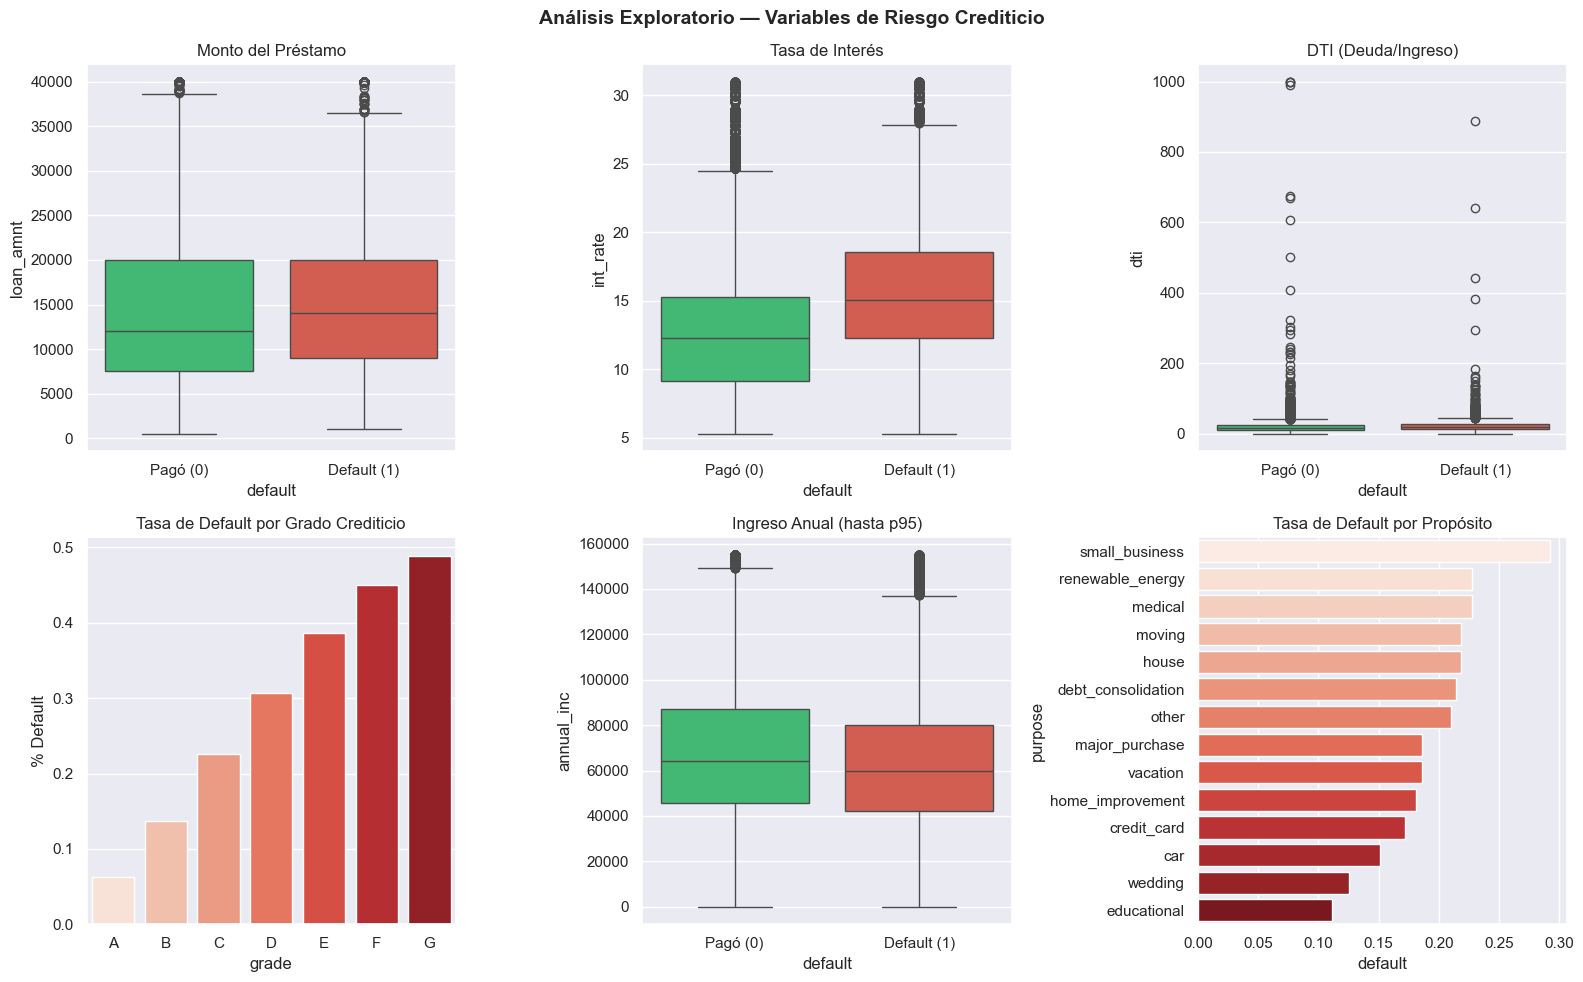

✅ Gráfico guardado en outputs/


In [8]:
# Variables financieras clave para riesgo crediticio
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Análisis Exploratorio — Variables de Riesgo Crediticio', fontsize=14, fontweight='bold')

# 1. Monto del préstamo por default
sns.boxplot(data=df_sample, x='default', y='loan_amnt', hue='default', ax=axes[0,0], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,0].set_title('Monto del Préstamo')
axes[0,0].set_xticks([0,1]); axes[0,0].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 2. Tasa de interés por default
sns.boxplot(data=df_sample, x='default', y='int_rate', hue='default', ax=axes[0,1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,1].set_title('Tasa de Interés')
axes[0,1].set_xticks([0,1]); axes[0,1].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 3. DTI por default
sns.boxplot(data=df_sample, x='default', y='dti', hue='default', ax=axes[0,2], palette=['#2ecc71','#e74c3c'], legend=False)
axes[0,2].set_title('DTI (Deuda/Ingreso)')
axes[0,2].set_xticks([0,1]); axes[0,2].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 4. Tasa de default por grado crediticio
grade_default = df_sample.groupby('grade')['default'].mean().reset_index()
sns.barplot(data=grade_default, x='grade', y='default', hue='grade', ax=axes[1,0], palette='Reds', legend=False)
axes[1,0].set_title('Tasa de Default por Grado Crediticio')
axes[1,0].set_ylabel('% Default')

# 5. Ingreso anual por default (cap en percentil 95)
income_cap = df_sample['annual_inc'].quantile(0.95)
df_plot = df_sample[df_sample['annual_inc'] <= income_cap]
sns.boxplot(data=df_plot, x='default', y='annual_inc', hue='default', ax=axes[1,1], palette=['#2ecc71','#e74c3c'], legend=False)
axes[1,1].set_title('Ingreso Anual (hasta p95)')
axes[1,1].set_xticks([0,1]); axes[1,1].set_xticklabels(['Pagó (0)', 'Default (1)'])

# 6. Default por propósito del préstamo
purpose_default = df_sample.groupby('purpose')['default'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=purpose_default, x='default', y='purpose', hue='purpose', ax=axes[1,2], palette='Reds', legend=False)
axes[1,2].set_title('Tasa de Default por Propósito')

plt.tight_layout()
#plt.savefig('../outputs/01_EDA_variables_riesgo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [9]:
# Análisis de valores nulos
nulos = df_sample.isnull().sum() / len(df_sample) * 100
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(f"Columnas con nulos: {len(nulos)}")
print(f"\nTop 20 columnas con más nulos:")
print(nulos.head(20).round(1))

# Selección de variables relevantes para riesgo crediticio
features = [
    'loan_amnt',       # Monto solicitado
    'int_rate',        # Tasa de interés
    'installment',     # Cuota mensual
    'grade',           # Grado crediticio
    'sub_grade',       # Subgrado
    'emp_length',      # Años de empleo
    'home_ownership',  # Tipo de vivienda
    'annual_inc',      # Ingreso anual
    'verification_status',  # Verificación de ingresos
    'purpose',         # Propósito del préstamo
    'dti',             # Ratio deuda/ingreso
    'delinq_2yrs',     # Mora en últimos 2 años
    'inq_last_6mths',  # Consultas crediticias últimos 6 meses
    'open_acc',        # Cuentas abiertas
    'pub_rec',         # Registros públicos negativos
    'revol_bal',       # Balance revolving
    'revol_util',      # Utilización línea revolving
    'total_acc',       # Total de cuentas
    'term'             # Plazo del préstamo
]

df_model = df_sample[features + ['default']].copy()
print(f"\n✅ Dataset de modelamiento: {df_model.shape}")
print(f"Nulos por variable:")
print(df_model.isnull().sum())

Columnas con nulos: 103

Top 20 columnas con más nulos:
id                                            100.0
member_id                                     100.0
url                                           100.0
next_pymnt_d                                  100.0
orig_projected_additional_accrued_interest     99.7
deferral_term                                  99.6
hardship_payoff_balance_amount                 99.6
hardship_amount                                99.6
hardship_dpd                                   99.6
hardship_loan_status                           99.6
hardship_type                                  99.6
hardship_start_date                            99.6
hardship_end_date                              99.6
hardship_status                                99.6
hardship_reason                                99.6
hardship_last_payment_amount                   99.6
payment_plan_start_date                        99.6
hardship_length                                99.6
sec_app_

In [10]:
# Limpieza y transformación de variables

# 1. Imputar nulos
df_model['emp_length'].fillna('Unknown', inplace=True)
df_model['dti'].fillna(df_model['dti'].median(), inplace=True)
df_model['revol_util'].fillna(df_model['revol_util'].median(), inplace=True)

# 2. Limpiar variables de texto
df_model['term'] = df_model['term'].str.strip().str.replace(' months', '').astype(int)
df_model['emp_length'] = df_model['emp_length'].str.replace('years', '').str.replace('year', '').str.replace('< 1', '0').str.replace('10+', '10').str.strip()
df_model['emp_length'] = pd.to_numeric(df_model['emp_length'], errors='coerce').fillna(0).astype(int)

# 3. Encoding de variables categóricas
from sklearn.preprocessing import LabelEncoder

cat_cols = ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print("✅ Limpieza completada")
print(f"\nTipos de datos finales:")
print(df_model.dtypes)
print(f"\nNulos restantes: {df_model.isnull().sum().sum()}")

/var/folders/hy/dm02ygv540jbfmqn4q4cbh9c0000gn/T/ipykernel_1958/1907698066.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['emp_length'].fillna('Unknown', inplace=True)
/var/folders/hy/dm02ygv540jbfmqn4q4cbh9c0000gn/T/ipykernel_1958/1907698066.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

✅ Limpieza completada

Tipos de datos finales:
loan_amnt                int64
int_rate               float64
installment            float64
grade                    int64
sub_grade                int64
emp_length               int64
home_ownership           int64
annual_inc             float64
verification_status      int64
purpose                  int64
dti                    float64
delinq_2yrs            float64
inq_last_6mths         float64
open_acc               float64
pub_rec                float64
revol_bal                int64
revol_util             float64
total_acc              float64
term                     int64
default                  int64
dtype: object

Nulos restantes: 0


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Variables predictoras y objetivo
X = df_model.drop('default', axis=1)
y = df_model['default']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"% Default en train: {y_train.mean()*100:.1f}%")
print(f"% Default en test:  {y_test.mean()*100:.1f}%")

# Escalar variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo base: Regresión Logística
print("\n⏳ Entrenando Regresión Logística...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Evaluación
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"\n=== RESULTADOS REGRESIÓN LOGÍSTICA ===")
print(f"AUC-ROC: {auc_lr:.4f}")

Train: 160,000 filas
Test:  40,000 filas
% Default en train: 20.2%
% Default en test:  20.2%

⏳ Entrenando Regresión Logística...

=== RESULTADOS REGRESIÓN LOGÍSTICA ===
AUC-ROC: 0.7043


In [13]:
from xgboost import XGBClassifier

# Modelo XGBoost
print("⏳ Entrenando XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,  # Ajuste por desbalance de clases
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

# Evaluación
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"\n=== RESULTADOS XGBOOST ===")
print(f"AUC-ROC: {auc_xgb:.4f}")

# Comparación de modelos
print(f"\n=== COMPARACIÓN ===")
print(f"Regresión Logística: {auc_lr:.4f}")
print(f"XGBoost:             {auc_xgb:.4f}")
print(f"Mejora:              +{(auc_xgb - auc_lr)*100:.2f} puntos")

⏳ Entrenando XGBoost...

=== RESULTADOS XGBOOST ===
AUC-ROC: 0.7105

=== COMPARACIÓN ===
Regresión Logística: 0.7043
XGBoost:             0.7105
Mejora:              +0.62 puntos



=== Regresión Logística ===
AUC-ROC : 0.7043
Gini    : 0.4085
KS Stat : 0.3007

=== XGBoost ===
AUC-ROC : 0.7105
Gini    : 0.4209
KS Stat : 0.3096


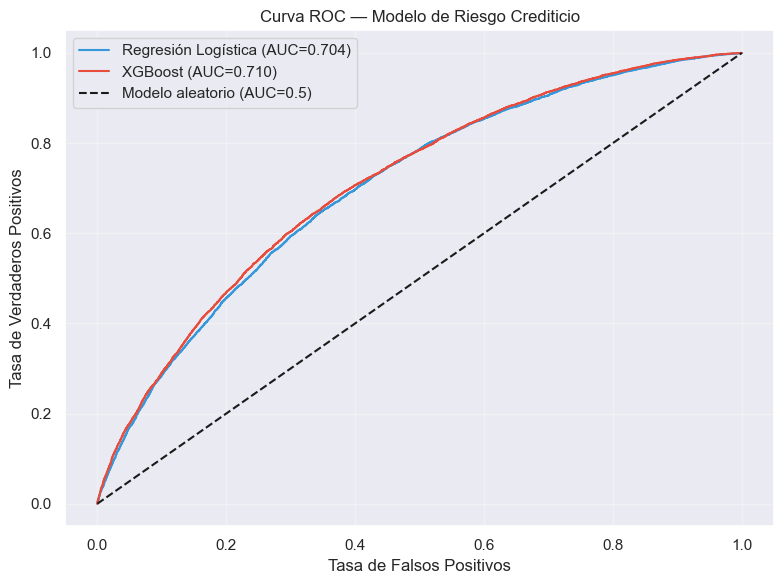

✅ Curva ROC guardada en outputs/


In [15]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular KS Statistic y Gini
def metricas_riesgo(y_true, y_proba, nombre_modelo):
    # AUC
    auc = roc_auc_score(y_true, y_proba)
    
    # Gini
    gini = 2 * auc - 1
    
    # KS Statistic
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    ks = max(tpr - fpr)
    
    print(f"\n=== {nombre_modelo} ===")
    print(f"AUC-ROC : {auc:.4f}")
    print(f"Gini    : {gini:.4f}")
    print(f"KS Stat : {ks:.4f}")
    
    return fpr, tpr, auc

# Métricas de ambos modelos
fpr_lr, tpr_lr, auc_lr = metricas_riesgo(y_test, y_pred_proba_lr, 'Regresión Logística')
fpr_xgb, tpr_xgb, auc_xgb = metricas_riesgo(y_test, y_pred_proba_xgb, 'XGBoost')

# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC={auc_lr:.3f})', color='#3498db')
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', color='#e74c3c')
ax.plot([0,1], [0,1], 'k--', label='Modelo aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Modelo de Riesgo Crediticio')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('../outputs/02_curva_ROC.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curva ROC guardada en outputs/")

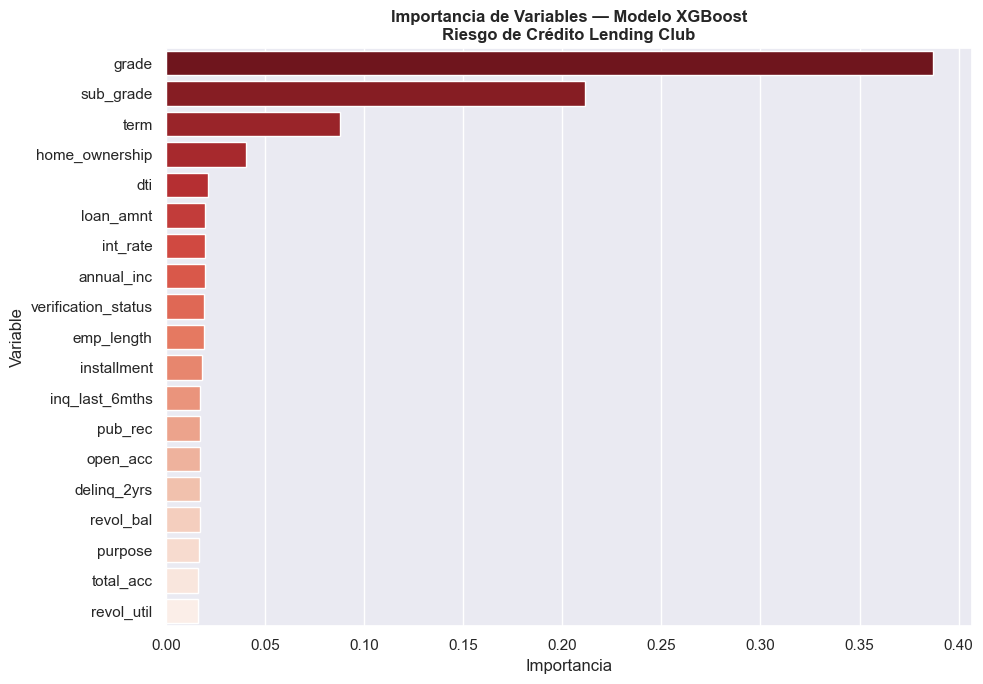


=== TOP 5 VARIABLES MÁS IMPORTANTES ===
          variable  importancia
3            grade     0.387289
4        sub_grade     0.211478
18            term     0.088087
6   home_ownership     0.040349
10             dti     0.021131


In [17]:
# Importancia de variables XGBoost
importancias = pd.DataFrame({
    'variable': X.columns,
    'importancia': xgb.feature_importances_
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=importancias, x='importancia', y='variable', 
            hue='variable', ax=ax, palette='Reds_r', legend=False)
ax.set_title('Importancia de Variables — Modelo XGBoost\nRiesgo de Crédito Lending Club', 
             fontweight='bold')
ax.set_xlabel('Importancia')
ax.set_ylabel('Variable')

plt.tight_layout()
#plt.savefig('../outputs/03_importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 VARIABLES MÁS IMPORTANTES ===")
print(importancias.head())

## 📊 Conclusiones del Modelo

### Resultados
| Métrica | Regresión Logística | XGBoost |
|---------|-------------------|---------|
| AUC-ROC | 0.7043 | 0.7105 |
| Gini | 0.4085 | 0.4209 |
| KS Stat | 0.3007 | 0.3096 |

### Hallazgos de Negocio
1. **El grado crediticio es el predictor más potente** (38.7% de importancia), 
   confirmando que la calificación interna de Lending Club captura bien el riesgo.
2. **La tasa de interés y el plazo** son señales fuertes — préstamos a 60 meses 
   tienen mayor probabilidad de default.
3. **El DTI** (ratio deuda/ingreso) aparece entre las 5 variables más relevantes, 
   consistente con la literatura de riesgo crediticio.
4. **20.1% de tasa de default** en el dataset — desbalance manejable que fue 
   corregido con `scale_pos_weight` en XGBoost.

### Conclusión
El modelo XGBoost supera el umbral AUC > 0.70 y KS > 0.30 requeridos 
en modelos de scoring crediticio institucional, usando solo 19 variables 
financieras sin optimización de hiperparámetros.